# Peramalan Harga Saham INDF — CNN-BiLSTM
**Revisi sesuai bimbingan 20-04-2026**

Perubahan dari versi sebelumnya:
- Grid parameter diperluas ke 3 nilai (16, 32, 64) untuk insight lebih kaya
- Dropout: [0.1, 0.2, 0.3] (3 nilai)
- Layer BiLSTM: [1, 2] (tetap)
- EPOCHS = 30 + EarlyStopping (val loss rata-rata sudah flat sebelum epoch 30)
- Windowing dilakukan dari data gabungan agar konteks antar segmen terjaga
- Normalisasi tidak perlu dipakai ----> belum diganti (diperlukan untuk kestabilan training deep learning)
- Inverse transform digunakan untuk mengembalikan prediksi ke satuan Rupiah
- Visualisasi prediksi vs aktual: hanya 1 grafik terbaik
- Label kategori akurasi (Sangat Akurat/Akurat) dihapus

## CELL 1 — Pra-Pemrosesan Data

--- ANALISIS AWAL DATA MENTAH ---
Total Hari Kerja Seharusnya : 2609 hari
Total Data Tersedia         : 2415 hari
Jumlah Data Hilang          : 194 hari


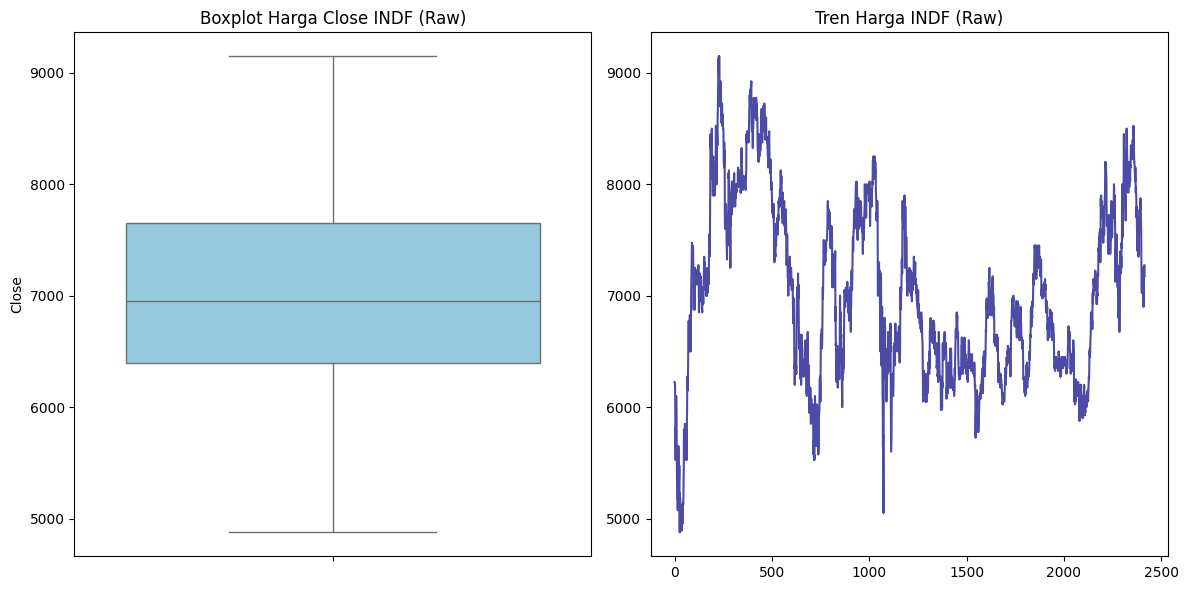


--- HASIL DETEKSI OUTLIER ---
Q1: 6400.0 | Q3: 7650.0 | IQR: 1250.0
Batas Bawah: 4525.0 | Batas Atas: 9525.0
Jumlah Outliers Terdeteksi: 0

✅ Tidak ditemukan outliers pada data mentah.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA & STANDARISASI KOLOM
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df = df_raw[['Tanggal', 'Terakhir']].rename(columns={'Tanggal': 'Date', 'Terakhir': 'Close'})

# 2. FORMAT TANGGAL & SORTIR
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
df = df.drop_duplicates(subset=['Date'], keep='first')

# 3. IDENTIFIKASI MISSING VALUES (Business Days)
all_business_days = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
missing_dates = all_business_days.difference(df['Date'])

print(f"--- ANALISIS AWAL DATA MENTAH ---")
print(f"Total Hari Kerja Seharusnya : {len(all_business_days)} hari")
print(f"Total Data Tersedia         : {len(df)} hari")
print(f"Jumlah Data Hilang          : {len(missing_dates)} hari")

# 4. DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=df['Close'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Harga Close INDF (Raw)')
axes[1].plot(df.index, df['Close'], color='navy', alpha=0.7)
axes[1].set_title('Tren Harga INDF (Raw)')
plt.tight_layout()
plt.show()

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"\n--- HASIL DETEKSI OUTLIER ---")
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")
print(f"Jumlah Outliers Terdeteksi: {len(outliers)}")
if len(outliers) > 0:
    print("\nDaftar Tanggal Outliers:")
    print(outliers)
else:
    print("\n✅ Tidak ditemukan outliers pada data mentah.")

|| MEMBUAT LIST TANGGAL YANG HILANG / MISSING VALUE ||

In [2]:
import pandas as pd

# 1. Load data mentah
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'], format='%d/%m/%Y')
df_raw = df_raw.sort_values('Tanggal')

# 2. Buat rentang hari kerja (Senin-Jumat) dari tanggal awal sampai akhir
full_range = pd.date_range(start=df_raw['Tanggal'].min(), end=df_raw['Tanggal'].max(), freq='B')

# 3. Cari tanggal yang ada di kalender hari kerja tapi tidak ada di dataset
missing_dates = full_range.difference(df_raw['Tanggal'])

# 4. Tampilkan hasil dalam bentuk tabel
missing_dates_df = pd.DataFrame(missing_dates, columns=['Tanggal_Kosong'])
missing_dates_df['Hari'] = missing_dates_df['Tanggal_Kosong'].dt.day_name() # Nama hari dalam Bahasa Inggris

print(f"Total Tanggal yang Hilang: {len(missing_dates_df)} hari")
print("\n--- 20 Tanggal Pertama yang Kosong ---")
print(missing_dates_df.head(20))

# Simpan ke CSV jika Anda ingin melihat daftar lengkapnya (194 hari)
missing_dates_df.to_csv('daftar_tanggal_kosong.csv', index=False)

Total Tanggal yang Hilang: 194 hari

--- 20 Tanggal Pertama yang Kosong ---
   Tanggal_Kosong       Hari
0      2015-12-09  Wednesday
1      2015-12-24   Thursday
2      2015-12-25     Friday
3      2015-12-31   Thursday
4      2016-01-01     Friday
5      2016-02-08     Monday
6      2016-03-09  Wednesday
7      2016-03-25     Friday
8      2016-05-05   Thursday
9      2016-05-06     Friday
10     2016-07-04     Monday
11     2016-07-05    Tuesday
12     2016-07-06  Wednesday
13     2016-07-07   Thursday
14     2016-07-08     Friday
15     2016-08-17  Wednesday
16     2016-09-12     Monday
17     2016-12-12     Monday
18     2016-12-26     Monday
19     2017-01-02     Monday


In [3]:
# Install semua library yang dibutuhkan
%pip install scikit-learn tensorflow pandas numpy matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from sklearn.preprocessing import MinMaxScaler

# 5. REINDEXING & INTERPOLASI
df_indexed = df.set_index('Date')
all_business_days = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='B')
df_complete = df_indexed.reindex(all_business_days)

# Interpolasi Polinomial Ordo 2
df_complete['Close'] = df_complete['Close'].interpolate(method='polynomial', order=2)
df_complete['Close'] = df_complete['Close'].ffill().bfill()

# 6. NORMALISASI
# Catatan: Normalisasi tetap digunakan meskipun univariate karena membantu
# kestabilan gradient descent pada deep learning (nilai input terbatas 0-1).
# Hasil prediksi akan di-inverse transform kembali ke satuan Rupiah.
scaler_global = MinMaxScaler(feature_range=(0, 1))
df_complete['Close_Scaled'] = scaler_global.fit_transform(df_complete[['Close']])

# Simpan hasil
df_final = df_complete.reset_index().rename(columns={'index': 'Date'})
df_final.to_csv('INDF_Cleaned.csv', index=False)

print(f"✅ Pra-pemrosesan Selesai!")
print(f"Total Baris Akhir : {len(df_final)}")
print(f"Rentang Tanggal   : {df_final['Date'].min()} s/d {df_final['Date'].max()}")
print(f"Data disimpan ke  : 'INDF_Cleaned.csv'")
print(df_final.head())

✅ Pra-pemrosesan Selesai!
Total Baris Akhir : 2609
Rentang Tanggal   : 2015-10-23 00:00:00 s/d 2025-10-22 00:00:00
Data disimpan ke  : 'INDF_Cleaned.csv'
        Date   Close  Close_Scaled
0 2015-10-23  6225.0      0.315789
1 2015-10-26  6225.0      0.315789
2 2015-10-27  6200.0      0.309942
3 2015-10-28  6075.0      0.280702
4 2015-10-29  5650.0      0.181287


## CELL 3 — Load Data & Fungsi Windowing

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

# Konversi ke float32 untuk hemat memory
for key in datasets:
    for k in ['X_train','y_train','X_val','y_val','X_test','y_test']:
        datasets[key][k] = datasets[key][k].astype(np.float32)
print("✅ Data dikonversi ke float32")

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)
✅ Data dikonversi ke float32

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model CNN-BiLSTM

In [4]:
# ============================================================
# CELL 5 — DEFINISI ARSITEKTUR MODEL CNN-BiLSTM
# ============================================================
# Lanjutan dari cell pembagian dataset (datasets sudah tersedia)

import time
import tensorflow as tf

# Batasi TensorFlow agar tidak ambil semua RAM sekaligus
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Bidirectional,
                                     LSTM, Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

# ----------------------------------------------------------
# FUNGSI BANGUN MODEL CNN-BiLSTM
# Parameter yang bisa di-tuning:
#   - n_filters     : jumlah filter Conv1D
#   - n_units       : jumlah unit BiLSTM per layer
#   - n_bilstm_layers : jumlah layer BiLSTM (1 atau 2)
#   - dropout_rate  : dropout untuk regularisasi
# ----------------------------------------------------------
def bangun_model(window_size, n_filters, n_units, n_bilstm_layers, dropout_rate):
    """
    Membangun model CNN-BiLSTM.
    Arsitektur:
      Conv1D → MaxPooling1D → Dropout
      → BiLSTM (1 atau 2 layer)
      → Dense(1) output
    """
    model = Sequential(name=f"CNN_BiLSTM_f{n_filters}_u{n_units}_l{n_bilstm_layers}")

    # === LAYER CNN — ekstrak pola lokal jangka pendek ===
    model.add(Conv1D(filters=n_filters,
                     kernel_size=3,
                     activation='relu',
                     padding='same',
                     input_shape=(window_size, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))


    # === LAYER BiLSTM — tangkap dependensi temporal dua arah ===
    if n_bilstm_layers == 1:
        model.add(Bidirectional(LSTM(n_units, return_sequences=False)))
        model.add(Dropout(dropout_rate))
    else:
        model.add(Bidirectional(LSTM(n_units, return_sequences=True)))
        model.add(Dropout(dropout_rate))
        model.add(Bidirectional(LSTM(n_units // 2, return_sequences=False)))
        model.add(Dropout(dropout_rate))

    # === OUTPUT LAYER ===
    model.add(Dense(1))

    # Compile dengan optimizer Adam & loss MSE (sesuai proposal)
    model.compile(optimizer='adam', loss='mse')
    
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    """
    Menghitung MAE, RMSE, MAPE, R2 setelah inverse transform
    sehingga metrik dalam satuan asli (Rupiah).
    """
    # Inverse transform: kembalikan ke satuan Rupiah
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    
    return mae, rmse, mape, r2


print("✅ Fungsi model dan metrik siap digunakan.")


✅ Fungsi model dan metrik siap digunakan.


## CELL 6 — Hyperparameter Tuning (Grid Search)

**Revisi grid parameter:**
- `n_filters` & `n_units` → 3 nilai [16, 32, 64] agar insight lebih kaya (bukan linier)
- `dropout_rate` → [0.1, 0.2, 0.3] (3 nilai)
- `n_bilstm_layers` → [1, 2] (tetap)
- `batch_size` → [16, 32, 64] (3 nilai, diuji bersamaan untuk hasil komprehensif)
- 3 × 3 × 2 × 3 × 3 = 162 kombinasi × 3 skenario = **486 kombinasi**

In [5]:
from itertools import product
import os
import gc
import tensorflow as tf

os.makedirs('models', exist_ok=True)

param_grid = {
    'n_filters'       : [16, 32, 64],
    'n_units'         : [16, 32, 64],
    'n_bilstm_layers' : [1, 2],
    'dropout_rate'    : [0.1, 0.2, 0.3],
    'batch_size'      : [16, 32, 64],
}

EPOCHS   = 30
PATIENCE = 10

skenario_list = ['80-10-10', '70-15-15', '60-20-20']
kombinasi     = list(product(
    param_grid['n_filters'],
    param_grid['n_units'],
    param_grid['n_bilstm_layers'],
    param_grid['dropout_rate'],
    param_grid['batch_size'],
))

total_kombi    = len(kombinasi)
total_skenario = len(skenario_list)
total_run      = total_kombi * total_skenario

print('=' * 70)
print('  HYPERPARAMETER TUNING CNN-BiLSTM')
print(f'  {total_kombi} kombinasi x {total_skenario} skenario = {total_run} total run')
print('=' * 70)

hasil_tuning   = []
history_tuning = {}  # simpan history top 1 per skenario
model_final    = {}  # simpan model top 1 per skenario

for nama_skenario in skenario_list:
    data    = datasets[nama_skenario]
    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']
    X_test  = data['X_test']
    y_test  = data['y_test']
    scaler  = data['scaler']

    print(f'\n>>> SKENARIO {nama_skenario}')
    print('-' * 70)

    best_mape_skenario    = float('inf')
    best_model_skenario   = None
    best_history_skenario = None
    best_nama_skenario    = None

    for idx, (n_filters, n_units, n_layers, dropout, batch_size) in enumerate(kombinasi, 1):
        tf.keras.backend.clear_session()  # bebaskan memory tiap iterasi
        gc.collect()

        nama = f'f{n_filters}_u{n_units}_l{n_layers}_d{int(dropout*10)}_b{batch_size}'
        print(f'  [{idx:03d}/{total_kombi}] {nama} ...', end=' ')

        model = bangun_model(
            window_size     = WINDOW_SIZE,
            n_filters       = n_filters,
            n_units         = n_units,
            n_bilstm_layers = n_layers,
            dropout_rate    = dropout
        )

        early_stop = EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0
        )

        waktu_mulai = time.time()
        history = model.fit(
            X_train, y_train,
            epochs          = EPOCHS,
            batch_size      = batch_size,
            validation_data = (X_val, y_val),
            callbacks       = [early_stop],
            verbose         = 0
        )
        durasi_detik   = time.time() - waktu_mulai
        epoch_berhenti = len(history.history['loss'])

        y_pred = model.predict(X_test, verbose=0)
        mae, rmse, mape, r2 = hitung_metrik(y_test, y_pred, scaler)

        hasil_tuning.append({
            'Nama'          : nama,
            'Skenario'      : nama_skenario,
            'Filter CNN'    : n_filters,
            'Unit BiLSTM'   : n_units,
            'Layer BiLSTM'  : n_layers,
            'Dropout'       : dropout,
            'Batch Size'    : batch_size,
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (detik)' : round(durasi_detik, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
            'R2'            : round(r2, 4),
        })

        print(f'Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | MAPE: {mape:.4f}% | R2: {r2:.4f}')

        # Simpan model terbaik per skenario (Opsi A)
        if mape < best_mape_skenario:
            best_mape_skenario    = mape
            best_model_skenario   = model
            best_history_skenario = history.history
            best_nama_skenario    = nama

    # Simpan model & history top 1 skenario ini
    key = f'{best_nama_skenario}_{nama_skenario}'
    model_final[key]    = best_model_skenario
    history_tuning[key] = best_history_skenario
    best_model_skenario.save(f'models/top1_{nama_skenario}_CNNBiLSTM.keras')
    print(f'  \u2705 Model top 1 skenario {nama_skenario} disimpan: {key}')

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning.to_csv('hasil_tuning_CNN_BiLSTM.csv', index=False)

# Top 1 per skenario
print('\n' + '=' * 70)
print('  TOP 1 KONFIGURASI PER SKENARIO')
print('=' * 70)
top1_per_skenario = {}
for nama_skenario in skenario_list:
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = subset.loc[subset['MAPE (%)'].idxmin()]
    top1_per_skenario[nama_skenario] = top1
    print(f'  {nama_skenario} -> {top1["Nama"]} | '
          f'MAE: {top1["MAE"]} | RMSE: {top1["RMSE"]} | MAPE: {top1["MAPE (%)"]}% | R2: {top1["R2"]}')

# Top 1 keseluruhan
best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]
print('\n' + '=' * 70)
print('  KONFIGURASI TERBAIK KESELURUHAN')
print('=' * 70)
print(f'  Nama         : {best_overall["Nama"]}')
print(f'  Skenario     : {best_overall["Skenario"]}')
print(f'  Filter CNN   : {int(best_overall["Filter CNN"])}')
print(f'  Unit BiLSTM  : {int(best_overall["Unit BiLSTM"])}')
print(f'  Layer BiLSTM : {int(best_overall["Layer BiLSTM"])}')
print(f'  Dropout      : {best_overall["Dropout"]}')
print(f'  Batch Size   : {int(best_overall["Batch Size"])}')
print(f'  MAE          : {best_overall["MAE"]}')
print(f'  RMSE         : {best_overall["RMSE"]}')
print(f'  MAPE         : {best_overall["MAPE (%)"]}%')
print(f'  R2           : {best_overall["R2"]}')
print(f'  Waktu        : {best_overall["Waktu (detik)"]} detik')
print("\n\u2705 Hasil tuning disimpan ke: 'hasil_tuning_CNN_BiLSTM.csv'")

# Siapkan variabel untuk cell berikutnya
konfigurasi_terbaik = {
    'nama'           : best_overall['Nama'],
    'n_filters'      : int(best_overall['Filter CNN']),
    'n_units'        : int(best_overall['Unit BiLSTM']),
    'n_bilstm_layers': int(best_overall['Layer BiLSTM']),
    'dropout_rate'   : float(best_overall['Dropout']),
    'batch_size'     : int(best_overall['Batch Size']),
}
best_skenario = best_overall['Skenario']
best_key      = f"{best_overall['Nama']}_{best_overall['Skenario']}"
best_mape     = best_overall['MAPE (%)']
best_mae      = best_overall['MAE']
best_rmse     = best_overall['RMSE']
best_r2       = best_overall['R2']
best_label    = f"CNN-BiLSTM ({best_overall['Nama']})"
skenario_final = ['80-10-10', '70-15-15', '60-20-20']

# df_final_hasil dari top1 per skenario
df_final_hasil = pd.DataFrame([
    {
        'Konfigurasi'   : top1_per_skenario[s]['Nama'],
        'Skenario'      : s,
        'Epoch Berhenti': top1_per_skenario[s]['Epoch Berhenti'],
        'Waktu (detik)' : top1_per_skenario[s]['Waktu (detik)'],
        'MAE'           : top1_per_skenario[s]['MAE'],
        'RMSE'          : top1_per_skenario[s]['RMSE'],
        'MAPE (%)'      : top1_per_skenario[s]['MAPE (%)'],
        'R2'            : top1_per_skenario[s]['R2'],
    }
    for s in skenario_final
])
df_final_hasil.to_csv('hasil_training_final_CNN_BiLSTM.csv', index=False)
print('\nRekap performa top 1 per skenario:')
print(df_final_hasil.to_string(index=False))


  HYPERPARAMETER TUNING CNN-BiLSTM
  162 kombinasi x 3 skenario = 486 total run

>>> SKENARIO 80-10-10
----------------------------------------------------------------------

  [001/162] f16_u16_l1_d1_b16 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 22 | Waktu: 43.36 dtk | MAPE: 2.0413% | R2: 0.6637
  [002/162] f16_u16_l1_d1_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 35.11 dtk | MAPE: 1.9034% | R2: 0.6886
  [003/162] f16_u16_l1_d1_b64 ... 

...

Epoch: 30 | Waktu: 51.91 dtk | MAPE: 1.3642% | R2: 0.9615
  [161/162] f64_u64_l2_d3_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 34.19 dtk | MAPE: 1.3553% | R2: 0.9612
  [162/162] f64_u64_l2_d3_b64 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 24.29 dtk | MAPE: 1.5166% | R2: 0.9519
  ✅ Model top 1 skenario 60-20-20 disimpan: f64_u64_l1_d1_b16_60-20-20

  TOP 1 KONFIGURASI PER SKENARIO
  80-10-10 -> f64_u64_l2_d1_b16 | MAE: 118.1635 | RMSE: 165.3872 | MAPE: 1.5428999662399292% | R2: 0.8126
  70-15-15 -> f32_u64_l1_d1_b16 | MAE: 99.5917 | RMSE: 146.0516 | MAPE: 1.3513000011444092% | R2: 0.96
  60-20-20 -> f64_u64_l1_d1_b16 | MAE: 84.7738 | RMSE: 126.1816 | MAPE: 1.173699975013733% | R2: 0.9707

  KONFIGURASI TERBAIK KESELURUHAN
  Nama         : f64_u64_l1_d1_b16
  Skenario     : 60-20-20
  Filter CNN   : 64
  Unit BiLSTM  : 64
  Layer BiLSTM : 1
  Dropout      : 0.1
  Batch Size   : 16
  MAE          : 84.7738
  RMSE         : 126.1816
  MAPE         : 1.173699975013733%
  R2           : 0.9707
  Waktu        : 31.77 detik

✅ Hasil tuning disimpan ke: 'hasil_tuning_CNN_BiLSTM.csv'

Rekap performa top 1 per skenario:
      Konfigurasi Skenario  Epoch Berhenti  Waktu (detik)      MAE     RMSE  MAPE (%)     R2


## CELL 7 — Visualisasi Trade-Off Tuning

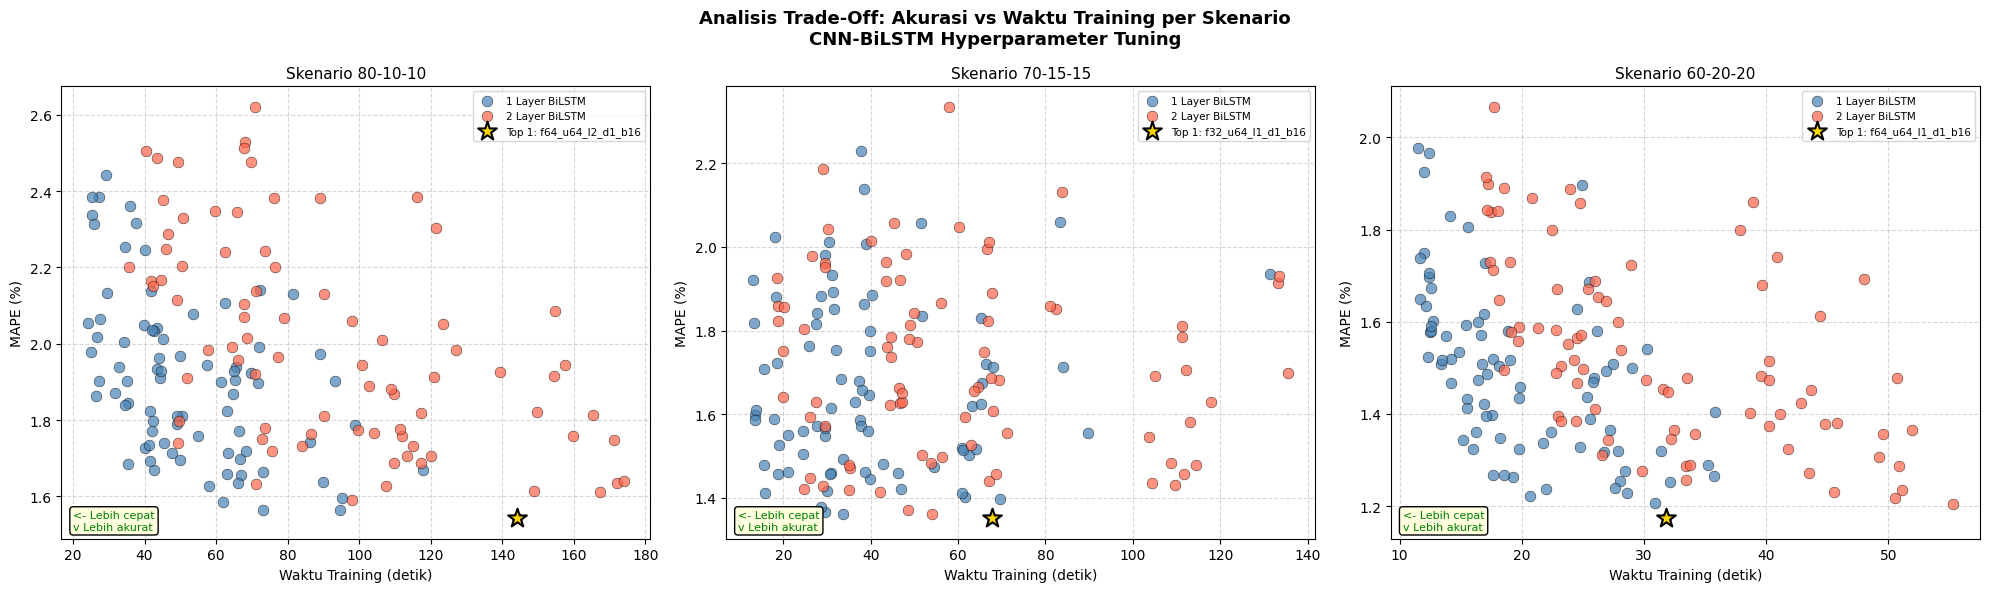

✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'


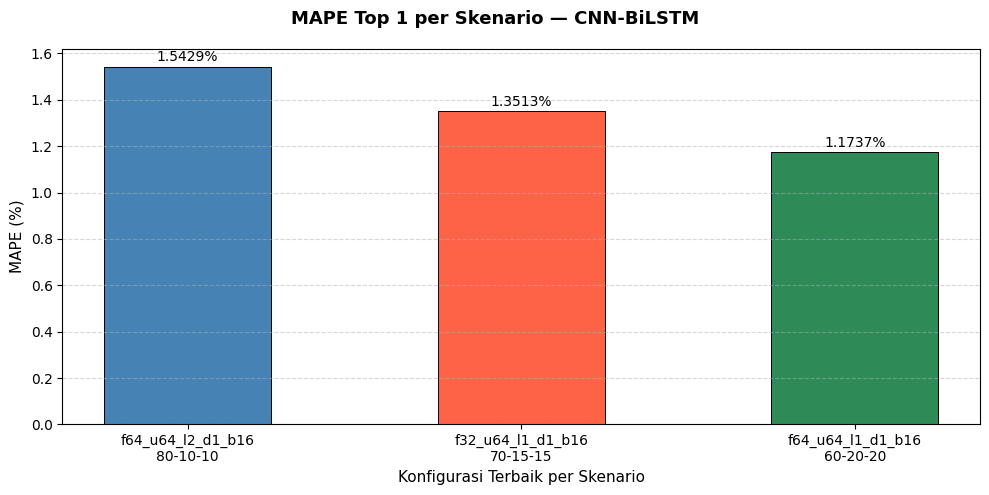

✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training per Skenario\n'
    'CNN-BiLSTM Hyperparameter Tuning',
    fontsize=13, fontweight='bold'
)

colors_layer = {1: 'steelblue', 2: 'tomato'}

for col_idx, nama_skenario in enumerate(skenario_list):
    ax     = axes[col_idx]
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = top1_per_skenario[nama_skenario]

    for n_layer in [1, 2]:
        s = subset[subset['Layer BiLSTM'] == n_layer]
        ax.scatter(
            s['Waktu (detik)'], s['MAPE (%)'],
            c=colors_layer[n_layer],
            label=f'{n_layer} Layer BiLSTM',
            s=60, edgecolors='black', linewidths=0.4, alpha=0.7, zorder=3
        )

    # Highlight top 1
    ax.scatter(
        [top1['Waktu (detik)']], [top1['MAPE (%)']],
        c='gold', s=200, edgecolors='black',
        linewidths=1.5, zorder=5, marker='*',
        label=f"Top 1: {top1['Nama']}"
    )

    ax.set_title(f'Skenario {nama_skenario}', fontsize=11)
    ax.set_xlabel('Waktu Training (detik)', fontsize=10)
    ax.set_ylabel('MAPE (%)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(
        '<- Lebih cepat\nv Lebih akurat',
        xy=(0.02, 0.02), xycoords='axes fraction',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )

plt.tight_layout()
plt.savefig('tradeoff_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'")

# Bar chart top 1 per skenario
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('MAPE Top 1 per Skenario — CNN-BiLSTM', fontsize=13, fontweight='bold')

nama_list = [top1_per_skenario[s]['Nama'] + '\n' + s for s in skenario_list]
mape_list = [top1_per_skenario[s]['MAPE (%)'] for s in skenario_list]
bars      = ax.bar(nama_list, mape_list, color=['steelblue', 'tomato', 'seagreen'],
                   edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, mape_list):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_xlabel('Konfigurasi Terbaik per Skenario', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top1_per_skenario.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'")


## CELL 9 — Loss Curve (Training vs Validation)

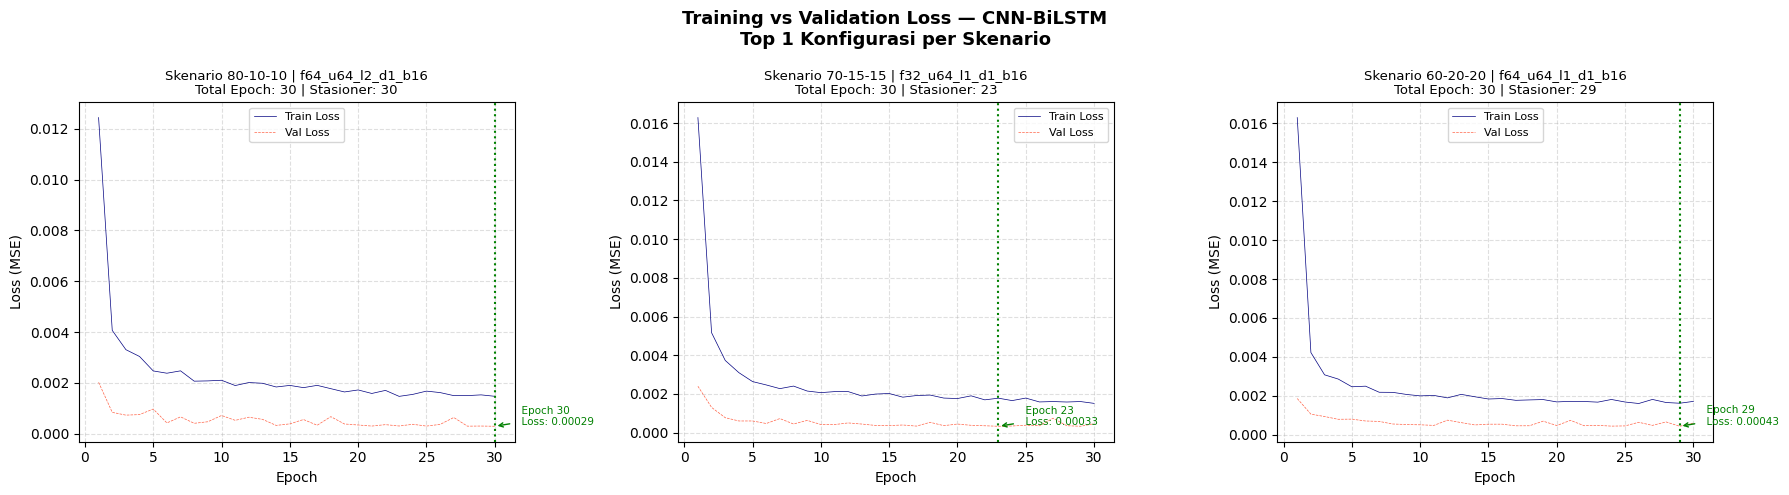

✅ Loss curve disimpan ke: loss_curve.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Training vs Validation Loss — CNN-BiLSTM\n'
    f'Top 1 Konfigurasi per Skenario',
    fontsize=13, fontweight='bold'
)

for col_idx, nama_skenario in enumerate(skenario_final):
    top1_nama = top1_per_skenario[nama_skenario]['Nama']
    key = f'{top1_nama}_{nama_skenario}'
    ax  = axes[col_idx]
    h   = history_tuning[key]

    total_epoch   = len(h['loss'])
    val_loss_arr  = np.array(h['val_loss'])
    best_epoch    = int(np.argmin(val_loss_arr)) + 1
    best_val_loss = val_loss_arr[best_epoch - 1]

    ax.plot(range(1, total_epoch + 1), h['loss'],
            label='Train Loss', color='navy', linewidth=0.5)
    ax.plot(range(1, total_epoch + 1), h['val_loss'],
            label='Val Loss', color='tomato',
            linewidth=0.5, linestyle='--')

    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
        fontsize=7.5, color='green',
        arrowprops=dict(arrowstyle='->', color='green', lw=1)
    )

    ax.set_title(
        f'Skenario {nama_skenario} | {top1_nama}\n'
        f'Total Epoch: {total_epoch} | Stasioner: {best_epoch}',
        fontsize=9.5
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curve disimpan ke: loss_curve.png')


## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

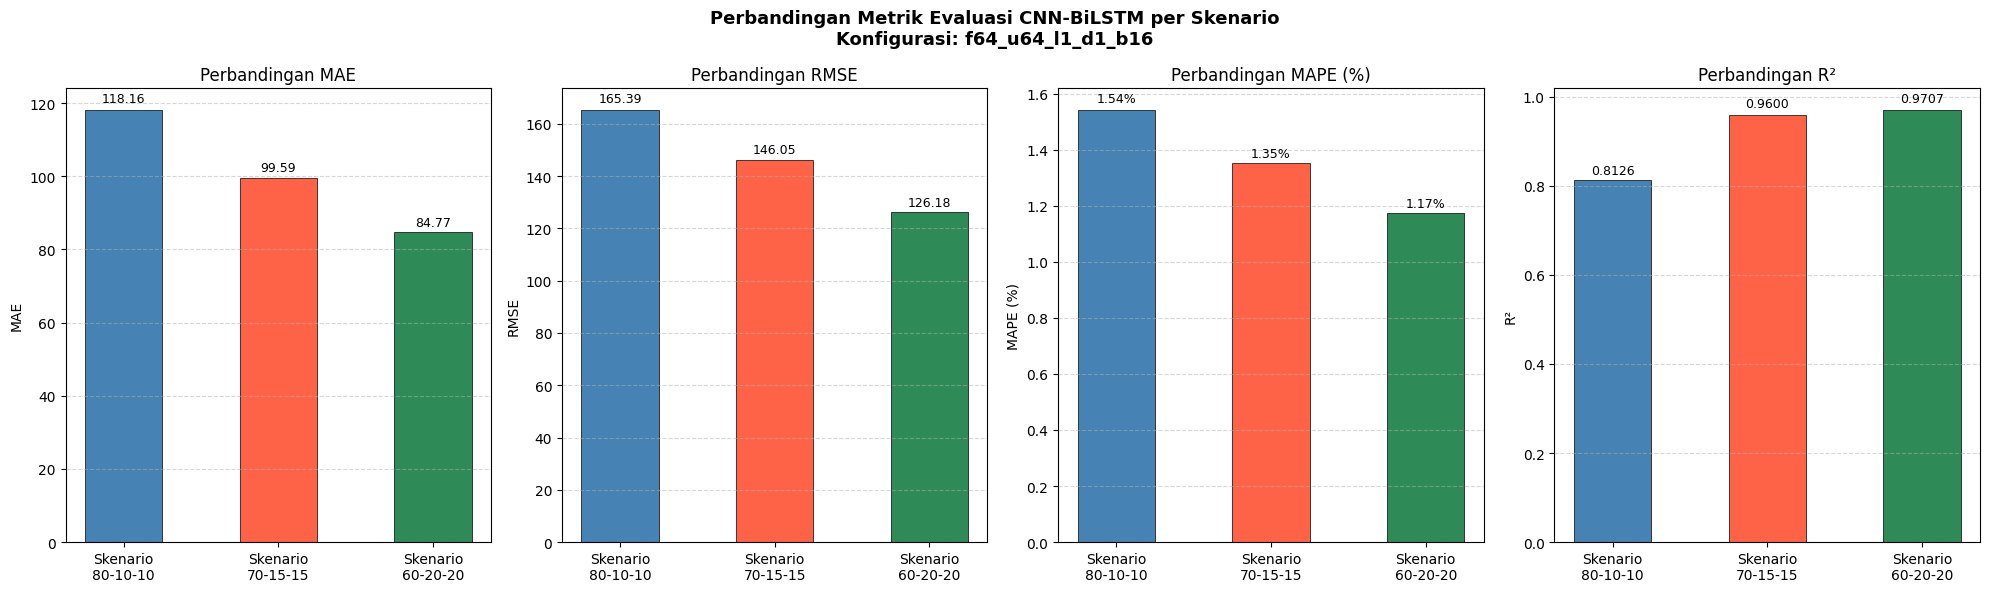


🏆 Performa terbaik:
   Skenario : 60-20-20
   MAE      : 84.77
   RMSE     : 126.18
   MAPE     : 1.173699975013733%
   R²       : 0.9707
   Waktu Training: 31.77 detik


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle(
    f'Perbandingan Metrik Evaluasi CNN-BiLSTM per Skenario\n'
    f'Konfigurasi: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
bar_colors   = ['steelblue', 'tomato', 'seagreen']

# Pastikan urutan skenario konsisten
df_plot = df_final_hasil.set_index('Skenario').loc[skenario_final].reset_index()

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax   = axes[i]
    vals = df_plot[metrik].values

    bars = ax.bar(
        [f'Skenario\n{s}' for s in skenario_final],
        vals, color=bar_colors,
        edgecolor='black', linewidth=0.5, width=0.5
    )

    for bar, val in zip(bars, vals):
        if metrik == 'MAPE (%)':
            txt = f'{val:.2f}%'
        elif metrik == 'R2':
            txt = f'{val:.4f}'   # R² perlu 4 desimal karena nilainya 0.xxxx
        else:
            txt = f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f"\n🏆 Performa terbaik:")
print(f"   Skenario : {best_row['Skenario']}")
print(f"   MAE      : {best_row['MAE']:.2f}")
print(f"   RMSE     : {best_row['RMSE']:.2f}")
print(f"   MAPE     : {best_row['MAPE (%)']}%")
print(f"   R²       : {best_row['R2']:.4f}")
print(f"   Waktu Training: {best_row['Waktu (detik)']} detik")


## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.

Model terbaik: f64_u64_l1_d1_b16_60-20-20
MAE: 84.77 | RMSE: 126.18 | MAPE: 1.1737% | R2: 0.9707 | Waktu: 31.77 dtk


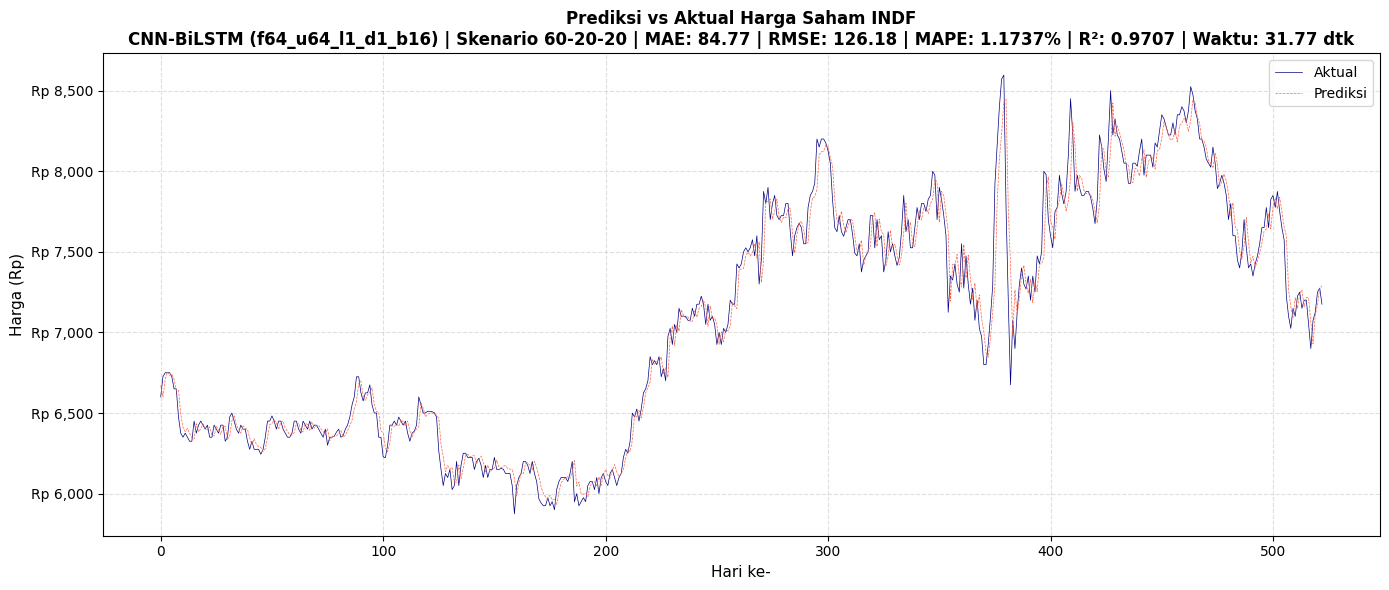

✅ Grafik prediksi disimpan ke: 'prediksi_vs_aktual_terbaik.png'


In [10]:
# Temukan model terbaik
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = f"CNN-BiLSTM ({best_row['Konfigurasi']})"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_waktu = best_row['Waktu (detik)']

print(f"Model terbaik: {best_key}")
print(f"MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R2: {best_r2:.4f} | Waktu: {best_waktu} dtk")

data = datasets[best_skenario]

# Prediksi ulang
y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)

# Inverse transform → satuan Rupiah
y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_true, label='Aktual', color='navy', linewidth=0.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=0.5, linestyle='--')

ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f} | Waktu: {best_waktu} dtk',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))

plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi disimpan ke: 'prediksi_vs_aktual_terbaik.png'")

## CELL 12 — Prediksi 1 Hari & 30 Hari ke Depan

Kedua prediksi dalam 1 cell menggunakan strategi **recursive forecasting**:
- Iterasi pertama = prediksi 1 hari (23 Oktober 2025)
- Setiap hasil prediksi dianggap aktual dan dimasukkan ke window berikutnya


  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN
  Model            : f64_u64_l1_d1_b16_60-20-20
  Data terakhir    : 22 October 2025 | Harga Close: Rp 7,175
  Tanggal prediksi : 23 October 2025
  Prediksi Harga   : Rp 7,187.07


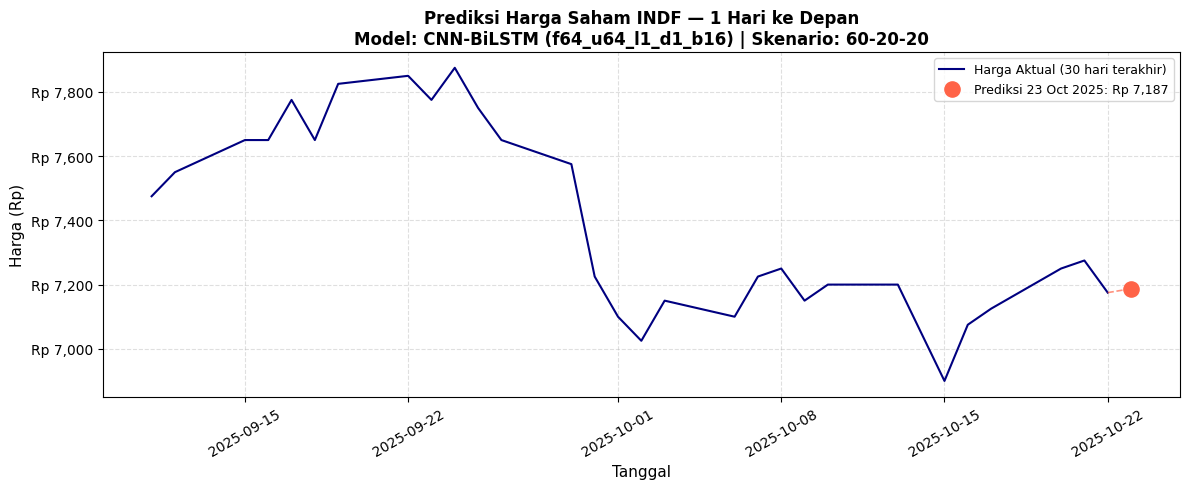

Grafik disimpan ke: 'prediksi_1hari.png'
  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN
  Model    : f64_u64_l1_d1_b16_60-20-20
  Strategi : Recursive Forecasting
  Mulai    : 23 October 2025
  Selesai  : 03 December 2025
         Tanggal  Prediksi (Rp)
 23 October 2025    7187.069824
 24 October 2025    7203.950195
 27 October 2025    7215.549805
 28 October 2025    7232.140137
 29 October 2025    7225.970215
 30 October 2025    7229.470215
 31 October 2025    7219.529785
03 November 2025    7202.669922
04 November 2025    7191.549805
05 November 2025    7167.689941
06 November 2025    7147.350098
07 November 2025    7127.140137
10 November 2025    7101.120117
11 November 2025    7087.629883
12 November 2025    7082.100098
13 November 2025    7082.169922
14 November 2025    7077.069824
17 November 2025    7075.259766
18 November 2025    7067.870117
19 November 2025    7054.580078
20 November 2025    7048.970215
21 November 2025    7041.669922
24 November 2025    7030.419922
25 Novembe

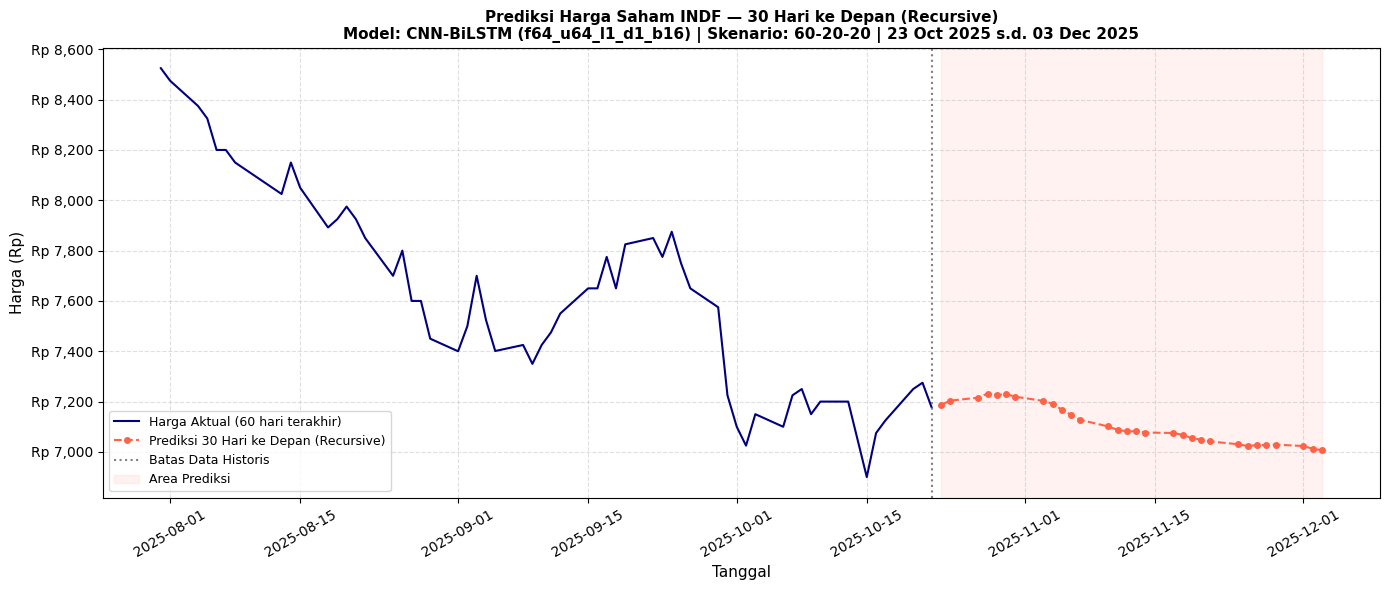

✅ Grafik disimpan ke: 'prediksi_30hari.png'


In [11]:
# ============================================================
# CELL 12 — PREDIKSI 1 HARI KE DEPAN
# ============================================================
# Input : WINDOW_SIZE (30) data terakhir dari seluruh dataset
# Output: prediksi harga penutupan 1 hari berikutnya (dalam Rupiah)

import pandas as pd
import numpy as np

# 1. Ambil model & scaler terbaik
model_terbaik  = model_final[best_key]
scaler_terbaik = datasets[best_skenario]['scaler']

# 2. Ambil WINDOW_SIZE data terakhir dari seluruh dataset
data_close_full = df[['Close']].values          # shape (N, 1)
last_window_raw = data_close_full[-WINDOW_SIZE:] # shape (30, 1)

# 3. Normalisasi menggunakan scaler yang sudah di-fit pada train set
last_window_scaled = scaler_terbaik.transform(last_window_raw)

# 4. Reshape ke format (1, WINDOW_SIZE, 1)
X_pred_1hari = last_window_scaled.reshape(1, WINDOW_SIZE, 1)

# 5. Prediksi (output skala 0-1)
pred_scaled = model_terbaik.predict(X_pred_1hari, verbose=0)

# 6. Inverse transform → satuan Rupiah
pred_rupiah = scaler_terbaik.inverse_transform(pred_scaled)[0][0]

# 7. Tentukan tanggal prediksi (1 hari kerja setelah data terakhir)
tanggal_terakhir = df.index[-1]
tanggal_prediksi = tanggal_terakhir + pd.offsets.BDay(1)

print("=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN")
print("=" * 55)
print(f"  Model            : {best_key}")
print(f"  Data terakhir    : {tanggal_terakhir.strftime('%d %B %Y')} "
      f"| Harga Close: Rp {data_close_full[-1][0]:,.0f}")
print(f"  Tanggal prediksi : {tanggal_prediksi.strftime('%d %B %Y')}")
print(f"  Prediksi Harga   : Rp {pred_rupiah:,.2f}")
print("=" * 55)

# Visualisasi: 30 hari historis + 1 titik prediksi
fig, ax = plt.subplots(figsize=(12, 5))

tanggal_historis = df.index[-WINDOW_SIZE:]
harga_historis   = data_close_full[-WINDOW_SIZE:].flatten()

ax.plot(tanggal_historis, harga_historis,
        label='Harga Aktual (30 hari terakhir)',
        color='navy', linewidth=1.5)

label_pred = f"Prediksi {tanggal_prediksi.strftime('%d %b %Y')}: Rp {pred_rupiah:,.0f}"
ax.scatter([tanggal_prediksi], [pred_rupiah],
           color='tomato', s=120, zorder=5, label=label_pred)

ax.plot([tanggal_historis[-1], tanggal_prediksi],
        [harga_historis[-1], pred_rupiah],
        color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_title(
    f'Prediksi Harga Saham INDF — 1 Hari ke Depan\n'
    f'Model: {best_label} | Skenario: {best_skenario}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_1hari.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan ke: 'prediksi_1hari.png'")


# ============================================================
# CELL 13 — PREDIKSI 30 HARI KE DEPAN (RECURSIVE FORECASTING)
# ============================================================
# Strategi recursive:
#   - Prediksi hari ke-1 (23 Okt) dianggap sebagai data aktual
#   - Masukkan ke window → prediksi hari ke-2 (24 Okt) → dst
#   - Error bisa terakumulasi semakin jauh prediksi

DAYS_AHEAD = 30

# 1. Window awal: 30 data terakhir (sudah dinormalisasi, dari Cell 12)
current_window = last_window_scaled.copy()  # shape (30, 1)

# 2. Prediksi rekursif
prediksi_list = []

for hari in range(DAYS_AHEAD):
    # Reshape ke (1, WINDOW_SIZE, 1)
    X_input = current_window.reshape(1, WINDOW_SIZE, 1)

    # Prediksi 1 langkah ke depan
    pred = model_terbaik.predict(X_input, verbose=0)[0][0]  # skala 0-1
    prediksi_list.append(pred)

    # Hasil prediksi dianggap aktual → geser window
    new_point      = np.array([[pred]])
    current_window = np.concatenate([current_window[1:], new_point], axis=0)

# 3. Inverse transform → satuan Rupiah
prediksi_scaled_arr = np.array(prediksi_list).reshape(-1, 1)
prediksi_rupiah_arr = scaler_terbaik.inverse_transform(prediksi_scaled_arr).flatten()

# 4. Buat daftar tanggal prediksi (hari kerja)
tanggal_awal = tanggal_terakhir + pd.offsets.BDay(1)
tanggal_pred = pd.date_range(start=tanggal_awal, periods=DAYS_AHEAD, freq='B')

# 5. Simpan ke DataFrame & CSV
df_prediksi_30 = pd.DataFrame({
    'Tanggal'       : tanggal_pred.strftime('%d %B %Y'),
    'Prediksi (Rp)' : prediksi_rupiah_arr.round(2)
})

print("=" * 50)
print("  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN")
print("=" * 50)
print(f"  Model    : {best_key}")
print(f"  Strategi : Recursive Forecasting")
print(f"  Mulai    : {tanggal_pred[0].strftime('%d %B %Y')}")
print(f"  Selesai  : {tanggal_pred[-1].strftime('%d %B %Y')}")
print("=" * 50)
print(df_prediksi_30.to_string(index=False))

df_prediksi_30.to_csv('prediksi_30hari_INDF.csv', index=False)
print("\n✅ Hasil disimpan ke: 'prediksi_30hari_INDF.csv'")

# 6. Visualisasi: 60 hari historis + 30 hari prediksi
LOOKBACK_VIS     = 60
tanggal_hist_vis = df.index[-LOOKBACK_VIS:]
harga_hist_vis   = data_close_full[-LOOKBACK_VIS:].flatten()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tanggal_hist_vis, harga_hist_vis,
        label='Harga Aktual (60 hari terakhir)',
        color='navy', linewidth=1.5)

ax.plot(tanggal_pred, prediksi_rupiah_arr,
        label='Prediksi 30 Hari ke Depan (Recursive)',
        color='tomato', linewidth=1.5,
        linestyle='--', marker='o', markersize=4)

ax.axvline(x=tanggal_terakhir, color='gray',
           linestyle=':', linewidth=1.5, label='Batas Data Historis')

ax.axvspan(tanggal_pred[0], tanggal_pred[-1],
           alpha=0.08, color='tomato', label='Area Prediksi')

tgl_mulai   = tanggal_pred[0].strftime('%d %b %Y')
tgl_selesai = tanggal_pred[-1].strftime('%d %b %Y')
ax.set_title(
    f'Prediksi Harga Saham INDF — 30 Hari ke Depan (Recursive)\n'
    f'Model: {best_label} | Skenario: {best_skenario} | '
    f'{tgl_mulai} s.d. {tgl_selesai}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_30hari.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan ke: 'prediksi_30hari.png'")
